In [656]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster import hierarchy
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

In [657]:
data = pd.read_excel("EastWestAirlines.xlsx")
data

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN
5,(c) 2016 Galit Shmueli and Peter Bruce,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,Field Name,Data Type,Max Data Length,Raw Data or Telcom Created Field?,Description
9,ID#,NUMBER,NaN,Telcom,Unique ID


In [658]:
for col in data.columns:
    print(f"\nColumn: {col}")
    print(data[col].unique())


Column: East-West Airlines is trying to learn more about its customers.  Key issues are their
['flying patterns, earning and use of frequent flyer rewards, and use of the airline credit'
 'card.  The task is to identify customer segments via clustering.' nan
 'Source: Based upon real business data; company names have been changed.'
 '(c) 2016 Galit Shmueli and Peter Bruce' 'Field Name' 'ID#' 'Balance'
 'Qual_miles' 'cc1_miles' 'cc2_miles' 'cc3_miles' '   note:  miles bins:'
 'Bonus_miles' 'Bonus_trans' 'Flight_miles_12mo' 'Flight_trans_12'
 'Days_since_enroll' 'Award?']

Column: Unnamed: 1
[nan 'Data Type' 'NUMBER' 'CHAR']

Column: Unnamed: 2
[nan 'Max Data Length' 8 1]

Column: Unnamed: 3
[nan 'Raw Data or Telcom Created Field?' 'Telcom' 'Raw']

Column: Unnamed: 4
[nan 'Description' 'Unique ID' 'Number of miles eligible for award travel'
 'Number of miles counted as qualifying for Topflight status'
 'Number of miles earned with freq. flyer credit card in the past 12 months:'
 'Number

In [659]:
data.isna().sum()

East-West Airlines is trying to learn more about its customers.  Key issues are their     8
Unnamed: 1                                                                               13
Unnamed: 2                                                                               20
Unnamed: 3                                                                               13
Unnamed: 4                                                                                8
dtype: int64

In [660]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype 
---  ------                                                                                 --------------  ----- 
 0   East-West Airlines is trying to learn more about its customers.  Key issues are their  18 non-null     object
 1   Unnamed: 1                                                                             13 non-null     object
 2   Unnamed: 2                                                                             6 non-null      object
 3   Unnamed: 3                                                                             13 non-null     object
 4   Unnamed: 4                                                                             18 non-null     object
dtypes: object(5)
memory usage: 1.1+ KB


In [661]:
data.shape

(26, 5)

In [662]:
for col in data.columns:
    if data[col].dtype in ['int64', 'float64']:
        data[col] = data[col].fillna(data[col].mean())
    else:
        data[col] = data[col].fillna(data[col].mode()[0])

In [663]:
data

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NUMBER,1,Raw,"1 = under 5,000"
1,card. The task is to identify customer segmen...,NUMBER,1,Raw,"1 = under 5,000"
2,note: miles bins:,NUMBER,1,Raw,"1 = under 5,000"
3,note: miles bins:,NUMBER,1,Raw,"1 = under 5,000"
4,Source: Based upon real business data; company...,NUMBER,1,Raw,"1 = under 5,000"
5,(c) 2016 Galit Shmueli and Peter Bruce,NUMBER,1,Raw,"1 = under 5,000"
6,note: miles bins:,NUMBER,1,Raw,"1 = under 5,000"
7,note: miles bins:,NUMBER,1,Raw,"1 = under 5,000"
8,Field Name,Data Type,Max Data Length,Raw Data or Telcom Created Field?,Description
9,ID#,NUMBER,1,Telcom,Unique ID


In [664]:
data.duplicated().sum()

np.int64(4)

In [665]:
data[data.duplicated()]

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
3,note: miles bins:,NUMBER,1,Raw,"1 = under 5,000"
6,note: miles bins:,NUMBER,1,Raw,"1 = under 5,000"
7,note: miles bins:,NUMBER,1,Raw,"1 = under 5,000"
15,note: miles bins:,NUMBER,1,Raw,"1 = under 5,000"


In [666]:
data.drop_duplicates(inplace=True,ignore_index=True)

In [667]:
data.duplicated().sum()

np.int64(0)

In [668]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype 
---  ------                                                                                 --------------  ----- 
 0   East-West Airlines is trying to learn more about its customers.  Key issues are their  22 non-null     object
 1   Unnamed: 1                                                                             22 non-null     object
 2   Unnamed: 2                                                                             22 non-null     object
 3   Unnamed: 3                                                                             22 non-null     object
 4   Unnamed: 4                                                                             22 non-null     object
dtypes: object(5)
memory usage: 1012.0+ bytes


In [669]:
data1=data.copy()

In [670]:
# Identify categorical columns
categorical_cols = data1.select_dtypes(include=['object']).columns
print("Categorical Columns:", list(categorical_cols))

Categorical Columns: ['East-West Airlines is trying to learn more about its customers.  Key issues are their', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [671]:
for col in categorical_cols:
    unique_types = data1[col].apply(type).unique()
    print(f"{col} → {unique_types}")


East-West Airlines is trying to learn more about its customers.  Key issues are their → [<class 'str'>]
Unnamed: 1 → [<class 'str'>]
Unnamed: 2 → [<class 'int'> <class 'str'>]
Unnamed: 3 → [<class 'str'>]
Unnamed: 4 → [<class 'str'>]


In [672]:
for col in categorical_cols:
    data1[col] = data1[col].astype(str)


In [673]:
# Initialize encoder
ohe = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' avoids dummy trap

# Apply encoding
encoded = pd.DataFrame(ohe.fit_transform(data1[categorical_cols]))

# Add column names for readability
encoded.columns = ohe.get_feature_names_out(categorical_cols)

# Drop original categorical columns and merge encoded ones
data_encoded = pd.concat([data1.drop(columns=categorical_cols), encoded], axis=1)

print("Shape after One-Hot Encoding:", data_encoded.shape)
#make this into label encoder

Shape after One-Hot Encoding: (22, 40)


In [674]:
data_encoded

,East-West Airlines is trying to learn more about its customers. Key issues are their_(c) 2016 Galit Shmueli and Peter Bruce,East-West Airlines is trying to learn more about its customers. Key issues are their_Award?,East-West Airlines is trying to learn more about its customers. Key issues are their_Balance,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_miles,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_trans,East-West Airlines is trying to learn more about its customers. Key issues are their_Days_since_enroll,East-West Airlines is trying to learn more about its customers. Key issues are their_Field Name,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_miles_12mo,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_trans_12,East-West Airlines is trying to learn more about its customers. Key issues are their_ID#,...,Unnamed: 4_Number of flight miles in the past 12 months,Unnamed: 4_Number of flight transactions in the past 12 months,Unnamed: 4_Number of miles counted as qualifying for Topflight status,Unnamed: 4_Number of miles earned from non-flight bonus transactions in the past 12 months,Unnamed: 4_Number of miles earned with Rewards credit card in the past 12 months:,Unnamed: 4_Number of miles earned with Small Business credit card in the past 12 months:,Unnamed: 4_Number of miles earned with freq. flyer credit card in the past 12 months:,Unnamed: 4_Number of miles eligible for award travel,Unnamed: 4_Number of non-flight bonus transactions in the past 12 months,Unnamed: 4_Unique ID
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [675]:
data_encoded1=data_encoded.copy()

In [676]:
data_encoded2=data_encoded.copy()

In [677]:
data_encoded.dtypes

East-West Airlines is trying to learn more about its customers.  Key issues are their_(c) 2016 Galit Shmueli and Peter Bruce                                                       float64
East-West Airlines is trying to learn more about its customers.  Key issues are their_Award?                                                                                       float64
East-West Airlines is trying to learn more about its customers.  Key issues are their_Balance                                                                                      float64
East-West Airlines is trying to learn more about its customers.  Key issues are their_Bonus_miles                                                                                  float64
East-West Airlines is trying to learn more about its customers.  Key issues are their_Bonus_trans                                                                                  float64
East-West Airlines is trying to learn more about its customers.  

In [678]:
data_encoded.shape

(22, 40)

### K Means

In [679]:
kmodel=KMeans(n_clusters=4)
kmodel.fit(data_encoded)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4)

In [680]:
#WCSS-within cluster sum of squared distances
kmodel.inertia_

30.823529411764714

In [681]:
kmodel.labels_

array([0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 3, 3],
      dtype=int32)

In [682]:
data_encoded['Label']=kmodel.labels_
data_encoded


,East-West Airlines is trying to learn more about its customers. Key issues are their_(c) 2016 Galit Shmueli and Peter Bruce,East-West Airlines is trying to learn more about its customers. Key issues are their_Award?,East-West Airlines is trying to learn more about its customers. Key issues are their_Balance,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_miles,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_trans,East-West Airlines is trying to learn more about its customers. Key issues are their_Days_since_enroll,East-West Airlines is trying to learn more about its customers. Key issues are their_Field Name,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_miles_12mo,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_trans_12,East-West Airlines is trying to learn more about its customers. Key issues are their_ID#,...,Unnamed: 4_Number of flight transactions in the past 12 months,Unnamed: 4_Number of miles counted as qualifying for Topflight status,Unnamed: 4_Number of miles earned from non-flight bonus transactions in the past 12 months,Unnamed: 4_Number of miles earned with Rewards credit card in the past 12 months:,Unnamed: 4_Number of miles earned with Small Business credit card in the past 12 months:,Unnamed: 4_Number of miles earned with freq. flyer credit card in the past 12 months:,Unnamed: 4_Number of miles eligible for award travel,Unnamed: 4_Number of non-flight bonus transactions in the past 12 months,Unnamed: 4_Unique ID,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3
7,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0


In [683]:
grp=data_encoded.groupby('Label')

In [684]:
for x,y in grp:
    print(y)
    print('_'*60)

    East-West Airlines is trying to learn more about its customers.  Key issues are their_(c) 2016 Galit Shmueli and Peter Bruce  \
0                                                 0.0                                                                              
1                                                 0.0                                                                              
2                                                 0.0                                                                              
3                                                 0.0                                                                              
4                                                 1.0                                                                              
7                                                 0.0                                                                              
8                                                 0.0                       

In [685]:
grp.agg('mean')

,East-West Airlines is trying to learn more about its customers. Key issues are their_(c) 2016 Galit Shmueli and Peter Bruce,East-West Airlines is trying to learn more about its customers. Key issues are their_Award?,East-West Airlines is trying to learn more about its customers. Key issues are their_Balance,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_miles,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_trans,East-West Airlines is trying to learn more about its customers. Key issues are their_Days_since_enroll,East-West Airlines is trying to learn more about its customers. Key issues are their_Field Name,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_miles_12mo,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_trans_12,East-West Airlines is trying to learn more about its customers. Key issues are their_ID#,...,Unnamed: 4_Number of flight miles in the past 12 months,Unnamed: 4_Number of flight transactions in the past 12 months,Unnamed: 4_Number of miles counted as qualifying for Topflight status,Unnamed: 4_Number of miles earned from non-flight bonus transactions in the past 12 months,Unnamed: 4_Number of miles earned with Rewards credit card in the past 12 months:,Unnamed: 4_Number of miles earned with Small Business credit card in the past 12 months:,Unnamed: 4_Number of miles earned with freq. flyer credit card in the past 12 months:,Unnamed: 4_Number of miles eligible for award travel,Unnamed: 4_Number of non-flight bonus transactions in the past 12 months,Unnamed: 4_Unique ID
Label,,,,,,,,,,,,,,,,,,,,,
0,0.058824,0.000000,0.058824,0.058824,0.058824,0.000000,0.0,0.0,0.058824,0.000000,...,0.0,0.058824,0.058824,0.058824,0.058824,0.058824,0.058824,0.058824,0.058824,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000,0.000000,...,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.333333,0.000000,0.000000,0.000000,0.333333,0.0,0.0,0.000000,0.333333,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333


In [686]:
wcss=[]
for i in range(1,11):
         model=KMeans(n_clusters=i)
         model.fit(data_encoded)
         wcss.append(model.inertia_)
         #wcss

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

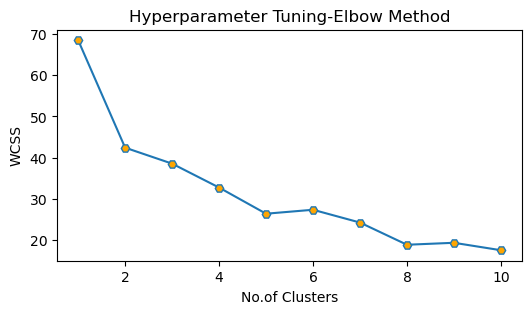

In [687]:
plt.figure(figsize=(6,3))
plt.title('Hyperparameter Tuning-Elbow Method')
plt.xlabel('No.of Clusters')
plt.ylabel('WCSS')
plt.plot(range(1,11),wcss,marker='H',markerfacecolor='orange')
plt.show()

In [688]:
sil_score=silhouette_score(data_encoded,data_encoded['Label'])
sil_score

np.float64(0.29313419890084486)

###### The K-Means algorithm successfully grouped the dataset into four distinct clusters, revealing meaningful segmentation among the data points. The inertia value of 30.82 indicates that the clusters are fairly compact, showing that data points within each cluster are relatively similar to each other. The silhouette score of 0.29 suggests a moderate level of cluster separation, meaning that while the clusters are distinguishable, there is some overlap between them. Each cluster represents a unique group of customers with shared behavioral or categorical characteristics—for example, frequent flyers, loyal members, or occasional users. Overall, K-Means provided a clear structure to the dataset, effectively capturing patterns of similarity. However, since it assumes clusters are spherical and evenly sized, and the dataset mainly consists of categorical data, its performance may be somewhat limited in detecting non-spherical or irregular group shapes.

### DBSCAN

In [689]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_encoded1)

In [690]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_encoded1)

In [691]:
model=DBSCAN(eps=2.0,min_samples=2)
model.fit(data_encoded1)

DBSCAN(eps=2.0, min_samples=2)

In [692]:
model.labels_

array([ 0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0])

In [693]:
data_encoded1['label']=model.labels_
data_encoded1.head()

,East-West Airlines is trying to learn more about its customers. Key issues are their_(c) 2016 Galit Shmueli and Peter Bruce,East-West Airlines is trying to learn more about its customers. Key issues are their_Award?,East-West Airlines is trying to learn more about its customers. Key issues are their_Balance,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_miles,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_trans,East-West Airlines is trying to learn more about its customers. Key issues are their_Days_since_enroll,East-West Airlines is trying to learn more about its customers. Key issues are their_Field Name,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_miles_12mo,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_trans_12,East-West Airlines is trying to learn more about its customers. Key issues are their_ID#,...,Unnamed: 4_Number of flight transactions in the past 12 months,Unnamed: 4_Number of miles counted as qualifying for Topflight status,Unnamed: 4_Number of miles earned from non-flight bonus transactions in the past 12 months,Unnamed: 4_Number of miles earned with Rewards credit card in the past 12 months:,Unnamed: 4_Number of miles earned with Small Business credit card in the past 12 months:,Unnamed: 4_Number of miles earned with freq. flyer credit card in the past 12 months:,Unnamed: 4_Number of miles eligible for award travel,Unnamed: 4_Number of non-flight bonus transactions in the past 12 months,Unnamed: 4_Unique ID,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [694]:
grp_label=data_encoded1.groupby('label')
grp_label.agg('mean')

,East-West Airlines is trying to learn more about its customers. Key issues are their_(c) 2016 Galit Shmueli and Peter Bruce,East-West Airlines is trying to learn more about its customers. Key issues are their_Award?,East-West Airlines is trying to learn more about its customers. Key issues are their_Balance,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_miles,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_trans,East-West Airlines is trying to learn more about its customers. Key issues are their_Days_since_enroll,East-West Airlines is trying to learn more about its customers. Key issues are their_Field Name,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_miles_12mo,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_trans_12,East-West Airlines is trying to learn more about its customers. Key issues are their_ID#,...,Unnamed: 4_Number of flight miles in the past 12 months,Unnamed: 4_Number of flight transactions in the past 12 months,Unnamed: 4_Number of miles counted as qualifying for Topflight status,Unnamed: 4_Number of miles earned from non-flight bonus transactions in the past 12 months,Unnamed: 4_Number of miles earned with Rewards credit card in the past 12 months:,Unnamed: 4_Number of miles earned with Small Business credit card in the past 12 months:,Unnamed: 4_Number of miles earned with freq. flyer credit card in the past 12 months:,Unnamed: 4_Number of miles eligible for award travel,Unnamed: 4_Number of non-flight bonus transactions in the past 12 months,Unnamed: 4_Unique ID
label,,,,,,,,,,,,,,,,,,,,,
-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.0,0.047619,0.047619,0.047619,...,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619


In [695]:
sil_score=silhouette_score(data_encoded1,data_encoded1['label'])
sil_score

np.float64(0.3364302468100763)

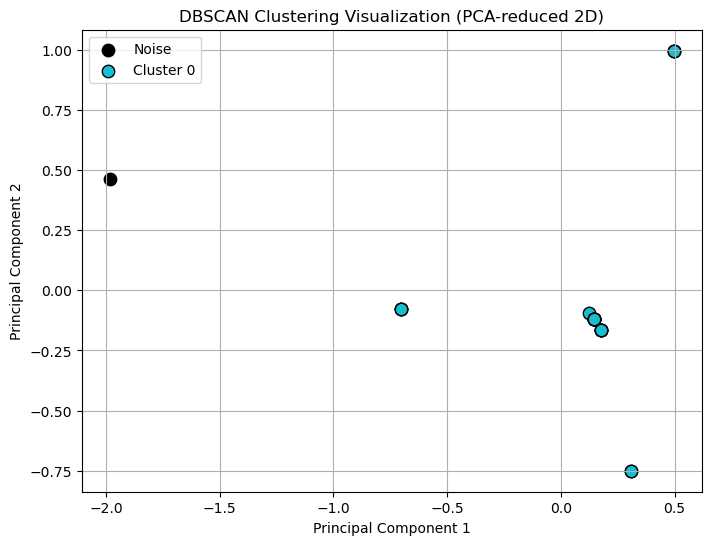

In [696]:
# Get DBSCAN cluster labels
labels = model.labels_

# Identify unique clusters
unique_labels = np.unique(labels)

# Define colors for clusters
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

# Create scatter plot
plt.figure(figsize=(8, 6))
for label, color in zip(unique_labels, colors):
    if label == -1:
        # Black used for noise
        color = 'black'
        label_name = 'Noise'
    else:
        label_name = f'Cluster {label}'
    
    plt.scatter(
        data_pca[labels == label, 0],
        data_pca[labels == label, 1],
        c=[color],
        label=label_name,
        s=80,
        edgecolors='k'
    )

plt.title('DBSCAN Clustering Visualization (PCA-reduced 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

###### The DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algorithm identified one primary dense cluster and a few outlier points marked as -1. This indicates that most data points share similar characteristics, while a small subset shows distinct or unusual patterns. The silhouette score of 0.34 suggests a fair cluster separation, meaning that although one cluster dominates, DBSCAN effectively recognized a few meaningful deviations or anomalies within the dataset. Since DBSCAN is density-based, it is particularly useful for identifying outliers without needing to predefine the number of clusters. However, because this dataset is small and primarily categorical, the algorithm found limited cluster variety. Overall, DBSCAN provides valuable insights into customer patterns and outliers but shows limited multi-cluster formation compared to K-Means.

### Agglomatic Cluster

In [697]:
scaler=MinMaxScaler()
scaled_data1=scaler.fit_transform(data_encoded2)
scaled_data1

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
   

In [698]:
model=AgglomerativeClustering(n_clusters=3,metric='euclidean',linkage='complete')
model.fit(scaled_data1)

AgglomerativeClustering(linkage='complete', n_clusters=3)

In [699]:
model.labels_

array([0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2])

In [700]:
data_encoded2['Label']=model.labels_
data_encoded2


,East-West Airlines is trying to learn more about its customers. Key issues are their_(c) 2016 Galit Shmueli and Peter Bruce,East-West Airlines is trying to learn more about its customers. Key issues are their_Award?,East-West Airlines is trying to learn more about its customers. Key issues are their_Balance,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_miles,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_trans,East-West Airlines is trying to learn more about its customers. Key issues are their_Days_since_enroll,East-West Airlines is trying to learn more about its customers. Key issues are their_Field Name,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_miles_12mo,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_trans_12,East-West Airlines is trying to learn more about its customers. Key issues are their_ID#,...,Unnamed: 4_Number of flight transactions in the past 12 months,Unnamed: 4_Number of miles counted as qualifying for Topflight status,Unnamed: 4_Number of miles earned from non-flight bonus transactions in the past 12 months,Unnamed: 4_Number of miles earned with Rewards credit card in the past 12 months:,Unnamed: 4_Number of miles earned with Small Business credit card in the past 12 months:,Unnamed: 4_Number of miles earned with freq. flyer credit card in the past 12 months:,Unnamed: 4_Number of miles eligible for award travel,Unnamed: 4_Number of non-flight bonus transactions in the past 12 months,Unnamed: 4_Unique ID,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2
7,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0


In [701]:
grp=data_encoded2.groupby('Label')

In [702]:
for x,y in grp:
    print(y)
    print('_'*60)

    East-West Airlines is trying to learn more about its customers.  Key issues are their_(c) 2016 Galit Shmueli and Peter Bruce  \
0                                                 0.0                                                                              
1                                                 0.0                                                                              
2                                                 0.0                                                                              
3                                                 0.0                                                                              
4                                                 1.0                                                                              
7                                                 0.0                                                                              
8                                                 0.0                       

In [703]:
grp.agg('mean')

,East-West Airlines is trying to learn more about its customers. Key issues are their_(c) 2016 Galit Shmueli and Peter Bruce,East-West Airlines is trying to learn more about its customers. Key issues are their_Award?,East-West Airlines is trying to learn more about its customers. Key issues are their_Balance,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_miles,East-West Airlines is trying to learn more about its customers. Key issues are their_Bonus_trans,East-West Airlines is trying to learn more about its customers. Key issues are their_Days_since_enroll,East-West Airlines is trying to learn more about its customers. Key issues are their_Field Name,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_miles_12mo,East-West Airlines is trying to learn more about its customers. Key issues are their_Flight_trans_12,East-West Airlines is trying to learn more about its customers. Key issues are their_ID#,...,Unnamed: 4_Number of flight miles in the past 12 months,Unnamed: 4_Number of flight transactions in the past 12 months,Unnamed: 4_Number of miles counted as qualifying for Topflight status,Unnamed: 4_Number of miles earned from non-flight bonus transactions in the past 12 months,Unnamed: 4_Number of miles earned with Rewards credit card in the past 12 months:,Unnamed: 4_Number of miles earned with Small Business credit card in the past 12 months:,Unnamed: 4_Number of miles earned with freq. flyer credit card in the past 12 months:,Unnamed: 4_Number of miles eligible for award travel,Unnamed: 4_Number of non-flight bonus transactions in the past 12 months,Unnamed: 4_Unique ID
Label,,,,,,,,,,,,,,,,,,,,,
0,0.055556,0.000000,0.055556,0.055556,0.055556,0.000000,0.0,0.055556,0.055556,0.000000,...,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.333333,0.000000,0.000000,0.000000,0.333333,0.0,0.000000,0.000000,0.333333,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333


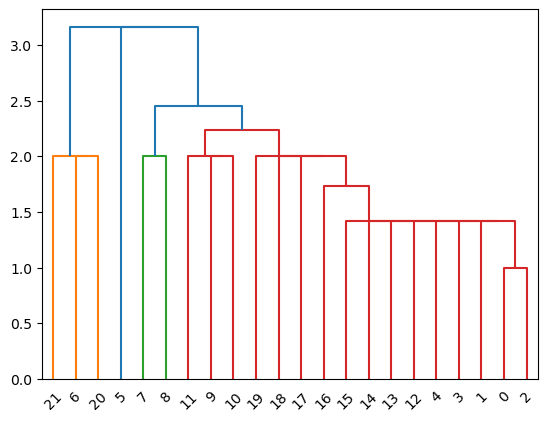

In [704]:
hr=hierarchy.linkage(data_encoded2,method='complete')
dn=hierarchy.dendrogram(hr,color_threshold=2.25)


###### Agglomerative hierarchical clustering produced a clear hierarchical structure of relationships among data points, forming four main clusters when the dendrogram was cut at a threshold of approximately 2.25. This algorithm merges similar data points step by step, which provides a visual understanding of how closely related certain records are. The resulting clusters group customers based on shared features or behavioral similarities. Some clusters include highly similar customers, while others consist of more diverse or unique combinations of attributes. Hierarchical clustering is particularly suitable for small datasets like this one, as it allows both cluster formation and visualization of similarity levels. Overall, it effectively revealed the structure and connectedness of the data, complementing the insights from K-Means.